# Retail Sales Analysis

## Project Objective

This notebook analyzes the Gold layer of a SQL Server data warehouse
to evaluate sales performance, customer behavior, product performance,
geographic patterns, and order fulfillment.

The analysis uses Python and Pandas to transform warehouse data into
business metrics and insights that can later support Power BI reporting.

## 1. Data Source

The analysis uses the business-ready Gold layer of the SQL Server
data warehouse.

The analytical model contains:

- `gold.fact_sales` — product-level sales transactions
- `gold.dim_customers` — customer demographic and geographic attributes
- `gold.dim_products` — product and category attributes
- `gold.dim_date` — calendar attributes

The source CRM and ERP datasets were previously cleaned, standardized,
integrated, and modeled through the Bronze, Silver, and Gold warehouse
layers.

## 2. Environment Setup

The required Python libraries are imported and a connection to the
SQL Server warehouse is established using SQLAlchemy and pyodbc.

In [2]:
import pandas as pd
import pyodbc

from sqlalchemy import create_engine
from urllib.parse import quote_plus

server = r"Nimi\SQLEXPRESS"
database = "DataWarehouse"

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

params = quote_plus(connection_string)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

In [3]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine



## 3. Load Gold Layer Data

The Gold fact and dimension objects are loaded directly from SQL Server
into Pandas DataFrames. The Gold layer remains the source of truth for
the analytical dataset.

In [4]:
fact_sales = pd.read_sql(
    "SELECT * FROM gold.fact_sales",
    engine
)

dim_customers = pd.read_sql(
    "SELECT * FROM gold.dim_customers",
    engine
)

dim_products = pd.read_sql(
    "SELECT * FROM gold.dim_products",
    engine
)

dim_date = pd.read_sql(
    "SELECT * FROM gold.dim_date",
    engine
)

## 4. Data Understanding and Validation

Before calculating business metrics, the datasets are inspected to
understand their structure, data types, missing values, uniqueness,
and analytical grain.

In [5]:
print("Fact sales:", fact_sales.shape)
print("Customers:", dim_customers.shape)
print("Products:", dim_products.shape)
print("Dates:", dim_date.shape)

Fact sales: (60398, 12)
Customers: (18484, 10)
Products: (295, 11)
Dates: (1139, 10)


In [6]:
fact_sales.info()
fact_sales.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_number       60398 non-null  str    
 1   product_key        60398 non-null  int64  
 2   customer_key       60398 non-null  int64  
 3   order_date_key     60379 non-null  float64
 4   shipping_date_key  60398 non-null  int64  
 5   due_date_key       60398 non-null  int64  
 6   order_date         60379 non-null  object 
 7   shipping_date      60398 non-null  object 
 8   due_date           60398 non-null  object 
 9   sales_amount       60398 non-null  float64
 10  quantity           60398 non-null  int64  
 11  price              60398 non-null  float64
dtypes: float64(3), int64(5), object(3), str(1)
memory usage: 5.5+ MB


order_number          0
product_key           0
customer_key          0
order_date_key       19
shipping_date_key     0
due_date_key          0
order_date           19
shipping_date         0
due_date              0
sales_amount          0
quantity              0
price                 0
dtype: int64

### 4.1 Fact Table Grain

Understanding the grain of the fact table is necessary before
calculating metrics such as order count, revenue, and units sold.

A row-count comparison with distinct orders is used to determine
whether one row represents an entire order or an individual sales line.

In [7]:
print(
    "Sales lines:",
    len(fact_sales)
)

print(
    "Unique orders:",
    fact_sales["order_number"].nunique()
)

print(
    "Units sold:",
    fact_sales["quantity"].sum()
)

Sales lines: 60398
Unique orders: 27659
Units sold: 60423


### Finding

The fact table contains:

- **60,398 sales lines**
- **27,659 distinct orders**
- **60,423 units sold**

The number of fact rows is greater than the number of distinct orders,
indicating that a single order can contain multiple product lines.

Therefore, the analytical grain of `fact_sales` is one product line
within a sales order.

As a result, total orders must be calculated using a distinct count
of `order_number` rather than the total number of fact-table rows.

### 4.2 Duplicate Validation

Duplicate checks are performed to verify that the fact table does not
contain repeated sales-line records.

In [8]:
print(
    "Exact duplicates:",
    fact_sales.duplicated().sum()
)

print(
    "Duplicate order-product combinations:",
    fact_sales.duplicated(
        subset=["order_number", "product_key"]
    ).sum()
)

Exact duplicates: 0
Duplicate order-product combinations: 0


### Finding

No exact duplicate rows or duplicate `order_number + product_key`
combinations were identified.

This supports the expected product-line grain of the fact table and
indicates that duplicate records should not distort subsequent
aggregations.

## 5. Executive KPI Overview

### Business Question

What is the overall scale and performance of the business?

The following metrics are calculated:

- Total Revenue
- Total Orders
- Units Sold
- Customers with Sales
- Products Sold
- Average Order Value
- Average Units per Order

### Metric Definitions

| KPI | Definition |
|---|---|
| **Total Revenue** | Total sales value generated across all sales lines. |
| **Total Orders** | Number of distinct sales orders. |
| **Units Sold** | Total quantity of products sold. |
| **Customers with Sales** | Number of distinct customers who appear in sales transactions. |
| **Products Sold** | Number of distinct products appearing in sales transactions. |
| **Average Order Value (AOV)** | Average revenue generated per order. |
| **Average Units per Order** | Average number of product units sold per order. |

In [9]:
total_revenue = fact_sales["sales_amount"].sum()

total_orders = fact_sales["order_number"].nunique()

units_sold = fact_sales["quantity"].sum()

customers_with_sales = fact_sales["customer_key"].nunique()

products_sold = fact_sales["product_key"].nunique()

average_order_value = total_revenue / total_orders

average_units_per_order = units_sold / total_orders

In [10]:
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Units Sold: {units_sold:,}")
print(f"Customers with Sales: {customers_with_sales:,}")
print(f"Products Sold: {products_sold:,}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Average Units per Order: {average_units_per_order:.2f}")

Total Revenue: 29,356,250.00
Total Orders: 27,659
Units Sold: 60,423
Customers with Sales: 18,484
Products Sold: 130
Average Order Value: 1,061.36
Average Units per Order: 2.18


In [11]:
print("Revenue nulls:", fact_sales["sales_amount"].isna().sum())
print("Quantity nulls:", fact_sales["quantity"].isna().sum())
print("Order number nulls:", fact_sales["order_number"].isna().sum())
print("Customer key nulls:", fact_sales["customer_key"].isna().sum())
print("Product key nulls:", fact_sales["product_key"].isna().sum())

Revenue nulls: 0
Quantity nulls: 0
Order number nulls: 0
Customer key nulls: 0
Product key nulls: 0


### Key Findings

The executive KPI analysis shows that:

- The business generated **[29,356,250.00]** in total revenue.
- **27,659 distinct orders** were recorded.
- **60,423 units** were sold.
- **[18,484] customers** made at least one purchase.
- **[130] products** were sold.
- Average Order Value was **[1,061.36]**.
- Customers purchased an average of approximately **2.18 units per order**.

## 6. Sales Trend Analysis

### Business Question

How has sales performance changed over time, and are there identifiable
growth patterns or seasonal trends?

This section evaluates:

- Annual revenue, orders, units sold, and customers
- Monthly sales performance
- Year-over-year revenue and order growth
- Seasonal patterns across calendar months

### 6.1 Annual Performance

#### Business Question

How have revenue, order volume, units sold, and the number of purchasing
customers changed from year to year?

In [12]:
fact_sales["order_date"] = pd.to_datetime(
    fact_sales["order_date"]
)

fact_sales["order_year"] = fact_sales["order_date"].dt.year.astype("Int64")
fact_sales["order_month"] = fact_sales["order_date"].dt.month.astype("Int64")
fact_sales["month_name"] = fact_sales["order_date"].dt.month_name()

fact_sales["month_start"] = (
    fact_sales["order_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)


In [13]:
fact_sales["order_year"].dtype

Int64Dtype()

In [14]:
fact_sales[
    [
        "order_date",
        "order_year",
        "order_month",
        "month_name",
        "month_start"
    ]
].head()

,order_date,order_year,order_month,month_name,month_start
0,2010-12-29,2010,12,December,2010-12-01
1,2010-12-29,2010,12,December,2010-12-01
2,2010-12-29,2010,12,December,2010-12-01
3,2010-12-29,2010,12,December,2010-12-01
4,2010-12-29,2010,12,December,2010-12-01


In [15]:
fact_sales["order_date"] = pd.to_datetime(
    fact_sales["order_date"]
)

fact_sales["order_year"] = (
    fact_sales["order_date"].dt.year
)

annual_sales = (
    fact_sales
    .groupby("order_year")
    .agg(
        revenue=("sales_amount", "sum"),
        orders=("order_number", "nunique"),
        units=("quantity", "sum"),
        customers=("customer_key", "nunique")
    )
    .reset_index()
)

annual_sales["order_year"] = (
    annual_sales["order_year"].astype("Int64")
)

annual_sales["average_order_value"] = (
    annual_sales["revenue"]
    / annual_sales["orders"]
)

annual_sales.round(2)

,order_year,revenue,orders,units,customers,average_order_value
0,2010,43419.0,14,14,14,3101.36
1,2011,7075088.0,2216,2216,2216,3192.73
2,2012,5842231.0,3269,3397,3255,1787.16
3,2013,16344878.0,21287,52807,17427,767.83
4,2014,45642.0,871,1970,834,52.40


In [16]:
annual_sales.dtypes

order_year               Int64
revenue                float64
orders                   int64
units                    int64
customers                int64
average_order_value    float64
dtype: object

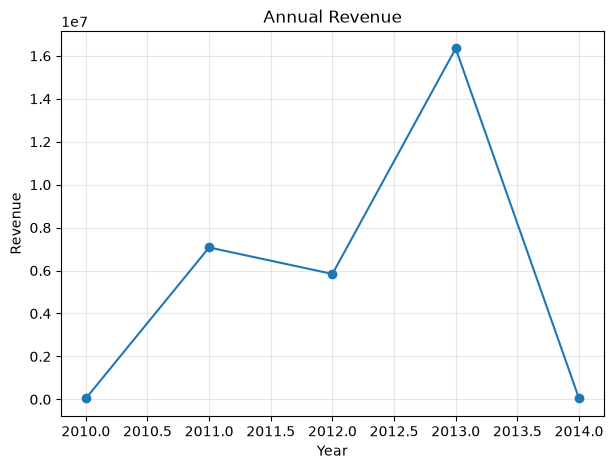

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    annual_sales["order_year"],
    annual_sales["revenue"],
    marker="o"
)

plt.title("Annual Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)

plt.show()

#### Findings

#### Findings

The dataset contains complete annual coverage for 2011–2013, while 2010
contains only the final three days of December and 2014 contains only the
first 28 days of January. Therefore, 2010 and 2014 are excluded from direct
full-year performance comparisons.

Among the complete years:

- **2013 recorded the highest revenue**, generating **16.34 million**.
- **2013 also recorded the highest order volume**, with **21,287 distinct orders**.
- Revenue decreased by approximately **17.43% from 2011 to 2012**, despite
  order volume increasing by approximately **47.52%**.
- Revenue then increased by approximately **179.77% from 2012 to 2013**,
  while order volume increased by approximately **551.18%**.
- Average Order Value declined from **1,787.16 in 2012 to 767.83 in 2013**.

This indicates that the strong revenue growth in 2013 was driven primarily
by a substantial increase in order volume rather than higher revenue per order.

### 6.2 Monthly Performance

#### Business Question

How did revenue, order volume, units sold, and customer activity change
month by month, and which complete months recorded the strongest and
weakest sales performance?

In [18]:
monthly_sales = (
    fact_sales
    .groupby("month_start")
    .agg(
        revenue=("sales_amount", "sum"),
        orders=("order_number", "nunique"),
        units=("quantity", "sum"),
        customers=("customer_key", "nunique")
    )
    .reset_index()
    .sort_values("month_start")
)


monthly_sales["average_order_value"] = (
    monthly_sales["revenue"]
    / monthly_sales["orders"]
).round(2)

monthly_sales.head()

,month_start,revenue,orders,units,customers,average_order_value
0,2010-12-01,43419.0,14,14,14,3101.36
1,2011-01-01,469795.0,144,144,144,3262.47
2,2011-02-01,466307.0,144,144,144,3238.24
3,2011-03-01,485165.0,150,150,150,3234.43
4,2011-04-01,502042.0,157,157,157,3197.72


In [19]:
print("First transaction:", fact_sales["order_date"].min())
print("Last transaction:", fact_sales["order_date"].max())

First transaction: 2010-12-29 00:00:00
Last transaction: 2014-01-28 00:00:00


In [20]:
complete_monthly_sales = monthly_sales[
    ~monthly_sales["month_start"].isin([
        pd.Timestamp("2010-12-01"),
        pd.Timestamp("2014-01-01")
    ])
].copy()

In [21]:
top_months = (
    complete_monthly_sales
    .nlargest(5, "revenue")
    [
        [
            "month_start",
            "revenue",
            "orders",
            "units",
            "customers",
            "average_order_value"
        ]
    ]
)

top_months

,month_start,revenue,orders,units,customers,average_order_value
36,2013-12-01,1874128.0,2192,5520,2133,854.99
35,2013-11-01,1780688.0,2087,5224,2036,853.23
34,2013-10-01,1673261.0,2131,5304,2073,785.20
30,2013-06-01,1642948.0,2007,5025,1948,818.61
32,2013-08-01,1545910.0,1964,4848,1898,787.12


In [22]:
bottom_months = (
    complete_monthly_sales
    .nsmallest(5, "revenue")
    [
        [
            "month_start",
            "revenue",
            "orders",
            "units",
            "customers",
            "average_order_value"
        ]
    ]
)

bottom_months

,month_start,revenue,orders,units,customers,average_order_value
17,2012-05-01,358866.0,207,207,207,1733.65
15,2012-03-01,373478.0,212,212,212,1761.69
16,2012-04-01,400324.0,219,219,219,1827.96
19,2012-07-01,444533.0,246,246,246,1807.04
2,2011-02-01,466307.0,144,144,144,3238.24


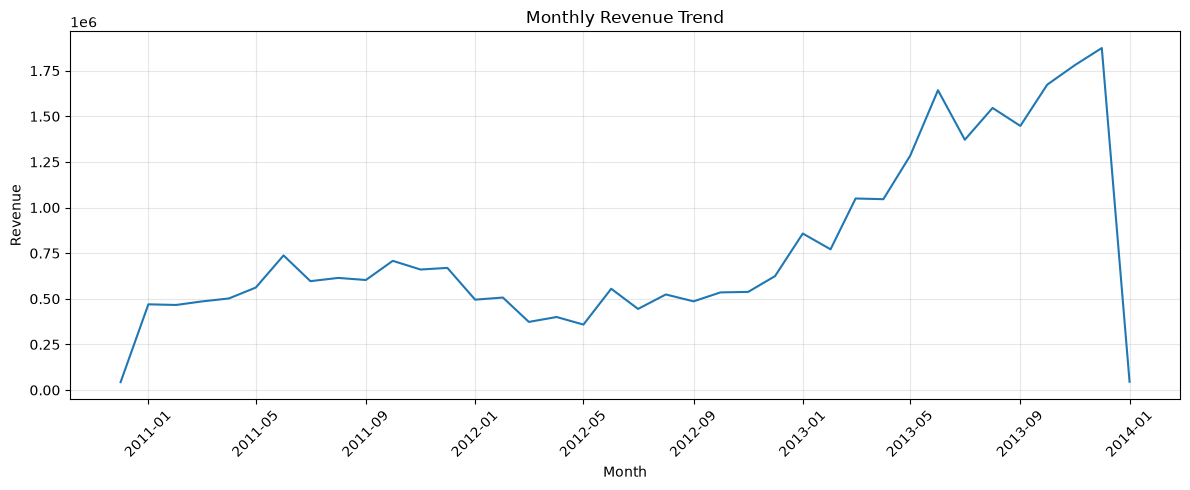

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["month_start"],
    monthly_sales["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

#### Findings

Monthly performance shows a substantial increase in sales activity during
2013 compared with earlier periods.

- **December 2013 was the strongest complete month**, generating approximately
  **1.87 million in revenue** from **2,192 orders** and **5,520 units sold**.
- The five highest-revenue months in the dataset all occurred during **2013**,
  reinforcing the strong annual performance observed for that year.
- **May 2012 was the weakest complete month**, generating approximately
  **358,866 in revenue** from **207 orders**.
- Several of the weakest months occurred during **2012**, which is consistent
  with the annual decline in revenue observed between 2011 and 2012.
- The strongest months in 2013 generated substantially more revenue despite
  having lower Average Order Values than some earlier months. This indicates
  that higher transaction volume was an important driver of monthly revenue
  growth.

December 2010 and January 2014 were excluded from the strongest/weakest month
comparison because they represent incomplete boundary months in the dataset.

### 6.3 Year-over-Year Growth

#### Business Question

How did revenue and order volume change from one complete year to the next,
and what factors contributed to those changes?

Only the complete years **2011–2013** are used for year-over-year comparisons.
The partial years 2010 and 2014 are excluded to avoid misleading comparisons.

In [24]:
complete_years = annual_sales[
    annual_sales["order_year"].isin([2011, 2012, 2013])
].copy()

complete_years["revenue_yoy_pct"] = (
    complete_years["revenue"]
    .pct_change()
    .mul(100)
)

complete_years["orders_yoy_pct"] = (
    complete_years["orders"]
    .pct_change()
    .mul(100)
)

complete_years.round(2)

,order_year,revenue,orders,units,customers,average_order_value,revenue_yoy_pct,orders_yoy_pct
1,2011,7075088.0,2216,2216,2216,3192.73,NaN,NaN
2,2012,5842231.0,3269,3397,3255,1787.16,-17.43,47.52
3,2013,16344878.0,21287,52807,17427,767.83,179.77,551.18


In [25]:
complete_years["aov_yoy_pct"] = (
    complete_years["average_order_value"]
    .pct_change()
    .mul(100)
)

In [26]:
complete_years[
    [
        "order_year",
        "revenue_yoy_pct",
        "orders_yoy_pct",
        "aov_yoy_pct"
    ]
].round(2)

,order_year,revenue_yoy_pct,orders_yoy_pct,aov_yoy_pct
1,2011,NaN,NaN,NaN
2,2012,-17.43,47.52,-44.02
3,2013,179.77,551.18,-57.04


#### Findings

Year-over-year analysis reveals a significant change in the drivers of
sales performance across the complete years.

- From **2011 to 2012**, revenue decreased by approximately **17.43%**,
  despite order volume increasing by approximately **47.52%**.
  Average Order Value declined substantially during the same period,
  indicating that the additional orders generated less revenue per order.

- From **2012 to 2013**, revenue increased by approximately **179.77%**,
  while order volume increased by approximately **551.18%**.
  Average Order Value declined further, but the substantial increase in
  transaction volume more than offset the lower revenue generated per order.

Overall, the results indicate that the major increase in 2013 sales
performance was primarily **volume-driven rather than value-driven**.

Further customer and product analysis is required to investigate the factors
associated with the increase in transaction volume and decline in Average
Order Value.

### 6.4 Seasonality

#### Business Question

Are there recurring monthly patterns in revenue and order activity that
suggest periods of stronger or weaker sales performance?

Only complete years (2011–2013) are included to ensure that partial
boundary months do not distort the seasonal averages.

In [27]:
year_month_sales = (
    fact_sales[
        fact_sales["order_year"].isin([2011, 2012, 2013])
    ]
    .groupby(
        ["order_year", "order_month", "month_name"]
    )
    .agg(
        revenue=("sales_amount", "sum"),
        orders=("order_number", "nunique")
    )
    .reset_index()
)

year_month_sales.head()

,order_year,order_month,month_name,revenue,orders
0,2011.0,1,January,469795.0,144
1,2011.0,2,February,466307.0,144
2,2011.0,3,March,485165.0,150
3,2011.0,4,April,502042.0,157
4,2011.0,5,May,561647.0,174


In [28]:
seasonality = (
    year_month_sales
    .groupby(
        ["order_month", "month_name"]
    )
    .agg(
        avg_monthly_revenue=("revenue", "mean"),
        avg_monthly_orders=("orders", "mean"),
        years_observed=("order_year", "nunique")
    )
    .reset_index()
    .sort_values("order_month")
)


In [29]:
seasonality.round(2)
seasonality.sort_values(
    "avg_monthly_revenue",
    ascending=False
)

,order_month,month_name,avg_monthly_revenue,avg_monthly_orders,years_observed
11,12,December,1.055992e+06,923.000000,3
10,11,November,9.930377e+05,873.000000,3
5,6,June,9.786277e+05,851.666667,3
9,10,October,9.721833e+05,888.333333,3
7,8,August,8.947710e+05,817.000000,3
8,9,September,8.455067e+05,779.333333,3
6,7,July,8.042793e+05,769.666667,3
4,5,May,7.349897e+05,724.333333,3
3,4,April,6.494087e+05,662.666667,3
2,3,March,6.361250e+05,684.000000,3


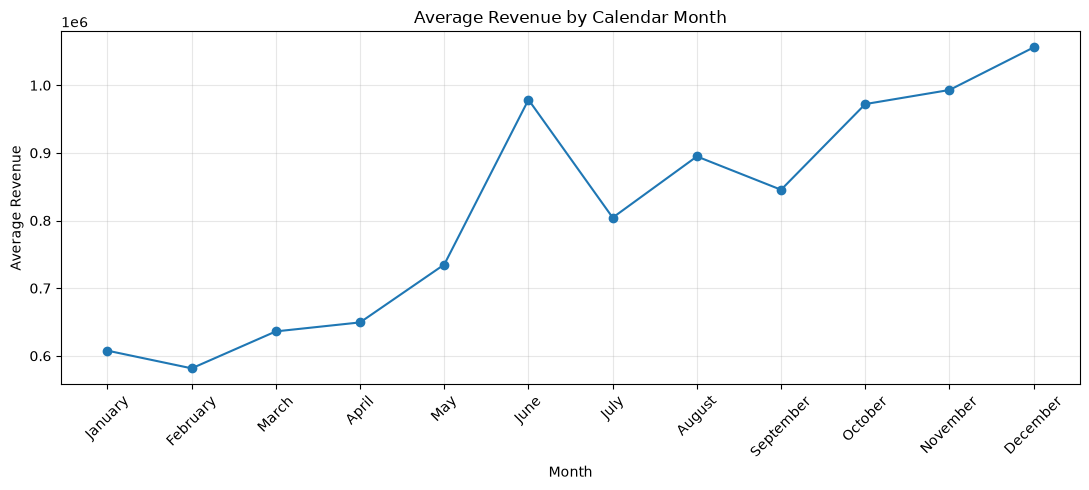

In [30]:
plt.figure(figsize=(11, 5))

plt.plot(
    seasonality["month_name"],
    seasonality["avg_monthly_revenue"],
    marker="o"
)

plt.title("Average Revenue by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Findings

Seasonality analysis across the complete years 2011–2013 suggests that
sales activity tends to be stronger during several months in the second
half of the year.

- **December recorded the highest average monthly revenue**, at approximately
  **1.06 million**, along with the highest average order volume at
  approximately **923 orders**.
- **November, June, and October** also recorded relatively strong average
  revenue, each approaching or exceeding **970,000**.
- **February recorded the lowest average monthly revenue**, at approximately
  **582,000**.
- October, November, and December all ranked among the stronger months,
  suggesting increased sales activity toward the end of the year.
- June also performed strongly, indicating that the observed pattern is not
  limited exclusively to year-end sales.

Because the analysis contains only three complete years of data, these
results suggest possible seasonal patterns rather than establishing a
definitive long-term seasonal trend.

## 7. Customer Analysis

The purpose of this section is to understand customer purchasing behavior,
identify high-value customers, measure purchase frequency, and evaluate the
importance of repeat customers.

### 7.1 Revenue by Customer

#### Business Question

Which customers generate the most revenue, and how concentrated is revenue
across the customer base?

In [31]:
customer_sales = fact_sales.merge(
    dim_customers,
    on="customer_key",
    how="left"
)

customer_sales.head()

,order_number,product_key,customer_key,order_date_key,shipping_date_key,due_date_key,order_date,shipping_date,due_date,sales_amount,...,month_start,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
0,SO43697,20,10769,20101229.0,20110105,20110110,2010-12-29,2011-01-05,2011-01-10,3578.0,...,2010-12-01,21768,AW00021768,Cole,Watson,Canada,Single,Male,1952-02-19,2026-01-05
1,SO43698,9,17390,20101229.0,20110105,20110110,2010-12-29,2011-01-05,2011-01-10,3400.0,...,2010-12-01,28389,AW00028389,Rachael,Martinez,France,Single,Female,1970-06-17,2026-01-25
2,SO43699,9,14864,20101229.0,20110105,20110110,2010-12-29,2011-01-05,2011-01-10,3400.0,...,2010-12-01,25863,AW00025863,Sydney,Wright,United States,Single,Female,1952-06-01,2026-01-14
3,SO43700,41,3502,20101229.0,20110105,20110110,2010-12-29,2011-01-05,2011-01-10,699.0,...,2010-12-01,14501,AW00014501,Ruben,Prasad,United States,Married,Male,1943-11-10,2025-10-12
4,SO43701,9,4,20101229.0,20110105,20110110,2010-12-29,2011-01-05,2011-01-10,3400.0,...,2010-12-01,11003,AW00011003,Christy,Zhu,Australia,Single,Female,1973-08-14,2025-10-06


In [32]:
customer_sales["customer_name"] = (
    customer_sales["first_name"].fillna("") 
    + " "
    + customer_sales["last_name"].fillna("")
).str.strip()

In [33]:
customer_summary = (
    customer_sales
    .groupby(
        ["customer_key","customer_name","country"]
        )
    .agg(
        total_revenue=("sales_amount", "sum"),
        total_orders=("order_number", "nunique"),
        total_units=("quantity", "sum")
    )
    .reset_index()
)
customer_summary["average_order_value"] = (
    customer_summary["total_revenue"]
    / customer_summary["total_orders"]
).round(2)

customer_summary["average_units_per_order"] = (
    customer_summary["total_units"]
    / customer_summary["total_orders"]
).round(2)

customer_summary.head()

,customer_key,customer_name,country,total_revenue,total_orders,total_units,average_order_value,average_units_per_order
0,1,Jon Yang,Australia,8249.0,3,8,2749.67,2.67
1,2,Eugene Huang,Australia,6384.0,3,11,2128.00,3.67
2,3,Ruben Torres,Australia,8114.0,3,4,2704.67,1.33
3,4,Christy Zhu,Australia,8139.0,3,9,2713.00,3.00
4,5,Elizabeth Johnson,Australia,8196.0,3,6,2732.00,2.00


In [34]:
print("Customers:", len(customer_summary))

print(
    "Revenue:",
    customer_summary["total_revenue"].sum()
)

print(
    "Orders:",
    customer_summary["total_orders"].sum()
)

Customers: 18484
Revenue: 29356250.0
Orders: 27659


In [35]:
fact_sales["order_number"].nunique()

27659

In [36]:
top_customers = (
    customer_summary
    .nlargest(10, "total_revenue")
    [
        [
            "customer_name",
            "country",
            "total_revenue",
            "total_orders",
            "total_units",
            "average_order_value"
        ]
    ]
)

top_customers

,customer_name,country,total_revenue,total_orders,total_units,average_order_value
1132,Kaitlyn Henderson,France,13294.0,5,14,2658.80
1301,Nichole Nara,France,13294.0,5,13,2658.80
1308,Margaret He,France,13268.0,5,14,2653.60
1131,Randall Dominguez,France,13265.0,5,11,2653.00
1300,Adriana Gonzalez,France,13242.0,5,10,2648.40
1321,Rosa Hu,France,13215.0,5,15,2643.00
1124,Brandi Gill,France,13195.0,5,12,2639.00
1307,Brad She,France,13172.0,5,11,2634.40
1296,Francisco Sara,France,13164.0,5,12,2632.80
433,Maurice Shan,France,12914.0,6,13,2152.33


In [37]:
dim_customers.columns

Index(['customer_key', 'customer_id', 'customer_number', 'first_name',
       'last_name', 'country', 'marital_status', 'gender', 'birthdate',
       'create_date'],
      dtype='str')

In [38]:
print(len(fact_sales))
print(len(customer_sales))
print(dim_customers["customer_key"].duplicated().sum())

60398
60398
0


In [39]:
top_customers

,customer_name,country,total_revenue,total_orders,total_units,average_order_value
1132,Kaitlyn Henderson,France,13294.0,5,14,2658.80
1301,Nichole Nara,France,13294.0,5,13,2658.80
1308,Margaret He,France,13268.0,5,14,2653.60
1131,Randall Dominguez,France,13265.0,5,11,2653.00
1300,Adriana Gonzalez,France,13242.0,5,10,2648.40
1321,Rosa Hu,France,13215.0,5,15,2643.00
1124,Brandi Gill,France,13195.0,5,12,2639.00
1307,Brad She,France,13172.0,5,11,2634.40
1296,Francisco Sara,France,13164.0,5,12,2632.80
433,Maurice Shan,France,12914.0,6,13,2152.33


In [40]:
total_customer_revenue= customer_summary["total_revenue"].sum()

customer_summary["revenue_share_pct"] = (
    customer_summary["total_revenue"]/ total_customer_revenue * 100
).round(4)

In [41]:
customer_summary = (
    customer_summary.sort_values(
        "total_revenue", 
        ascending=False
        )
        .reset_index(drop=True)
        )

In [42]:
top_10_pct_count = int(
    len(customer_summary) * 0.10
)
top_10_pct_count

1848

In [43]:
top_10_pct_revenue= (
    customer_summary
    .head(top_10_pct_count)["total_revenue"]
    .sum()
)

top_10_pct_revenue_share =(
    top_10_pct_revenue 
    / total_customer_revenue 
    * 100
)

print(
    "Top 10% customer revenue share:",
      round(top_10_pct_revenue_share,2),"%"
      )

Top 10% customer revenue share: 40.27 %


In [44]:
top_20_pct_count = int(
    len(customer_summary) * 0.20
)

top_20_pct_revenue = (
    customer_summary
    .head(top_20_pct_count)["total_revenue"]
    .sum()
)

top_20_pct_revenue_share = (
    top_20_pct_revenue
    / total_customer_revenue
    * 100
)

print(
    "Top 20% customer revenue share:",
    round(top_20_pct_revenue_share, 2),
    "%"
)

Top 20% customer revenue share: 66.4 %


In [45]:
customer_summary[
    [
        "total_revenue",
        "total_orders",
        "total_units",
        "average_order_value"
    ]
].describe().round(2)

,total_revenue,total_orders,total_units,average_order_value
count,18484.00,18484.0,18484.00,18484.00
mean,1588.20,1.5,3.27,911.78
std,2124.16,1.1,2.63,1040.79
min,2.00,1.0,1.00,2.00
25%,50.00,1.0,2.00,40.00
50%,271.50,1.0,3.00,157.00
75%,2511.00,2.0,4.00,1770.50
max,13294.00,28.0,68.00,3578.00


#### Findings

Customer revenue is unevenly distributed across the customer base.

- The **top 10% of customers generated approximately 40.27% of total revenue**,
  while the **top 20% generated approximately 66.40%**. This indicates that
  higher-value customers contribute a substantial share of overall revenue,
  although the distribution does not follow a strict 80/20 pattern.

- Average revenue per customer was approximately **1,588.20**, while the
  median was only **271.50**. The large difference between the mean and median
  indicates a right-skewed revenue distribution, where a smaller group of
  high-value customers raises the overall average.

- The median customer placed **1 order**, compared with an average of
  approximately **1.50 orders per customer**. The most active customer placed
  **28 orders**, showing considerable variation in purchasing frequency.

- The highest observed customer revenue was **13,294**, further demonstrating
  the difference between high-value customers and the typical customer.

Overall, the results show that revenue is concentrated among higher-value
customers while many customers make relatively few purchases. Purchase
frequency and repeat-customer behavior should therefore be examined further
to understand the customer base more clearly.

### 7.2 Purchase Frequency

#### Business Question

How frequently do customers place orders, and what proportion of the customer
base makes only one purchase versus multiple purchases?

In [46]:
purchase_frequency = (
    customer_summary["total_orders"]
    .value_counts()
    .sort_index()
    .reset_index()
)

purchase_frequency.columns = [
    "number_of_orders",
    "customer_count"
]

purchase_frequency["customer_pct"] = (
    purchase_frequency["customer_count"] / len(customer_summary) * 100
).round(2)
purchase_frequency

,number_of_orders,customer_count,customer_pct
0,1,11619,62.86
1,2,5454,29.51
2,3,1166,6.31
3,4,150,0.81
4,5,51,0.28
5,6,5,0.03
6,7,4,0.02
7,16,14,0.08
8,17,7,0.04
9,25,1,0.01


In [47]:
one_time_customers = (
    customer_summary["total_orders"] == 1
).sum()

repeat_customers = (
    customer_summary["total_orders"] > 1
).sum()

print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)


One-time customers: 11619
Repeat customers: 6865


In [48]:
total_customers = len(customer_summary)

one_time_pct = (
    one_time_customers / total_customers * 100
)

repeat_pct = (
    repeat_customers / total_customers * 100
)
print("One-time customer percentage:",
      round(one_time_pct,2),"%"
      )

print(
    "Repeat customer percentage:",
    round(repeat_pct, 2),"%"
)

print(one_time_customers + repeat_customers)
print(one_time_pct + repeat_pct)

One-time customer percentage: 62.86 %
Repeat customer percentage: 37.14 %
18484
100.0


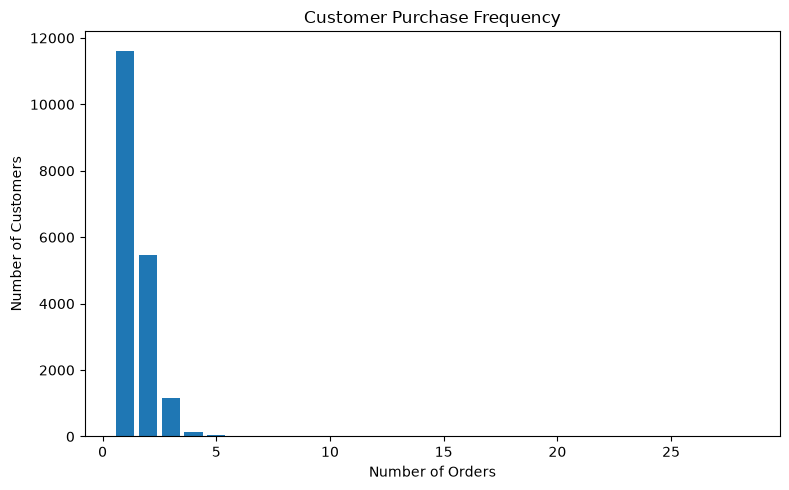

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    purchase_frequency["number_of_orders"],
    purchase_frequency["customer_count"]
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

#### Findings

Customer purchasing activity is heavily concentrated among low-frequency
buyers.

- **11,619 customers (62.86%) placed only one order** during the observed
  period.
- **6,865 customers (37.14%) placed more than one order**.
- Customers placing exactly **two orders represented 29.51%** of the customer
  base.
- Combining one- and two-order customers shows that approximately **92.37%**
  of customers placed no more than two orders.
- Only approximately **7.63% of customers placed three or more orders**,
  indicating that high-frequency purchasing was relatively uncommon in the
  observed data.

These results show that most customers made relatively few purchases during
the available observation period. However, purchase frequency alone should
not be interpreted as a customer retention rate because customers may have
different lengths of purchasing history within the dataset.

### 7.3 Repeat Customer Analysis

#### Business Question

How do one-time and repeat customers differ in their contribution to revenue,
orders, and purchasing value?

In [50]:
customer_summary["customer_type"] = (
    customer_summary["total_orders"]
    .apply(
        lambda x: "Repeat Customer"
        if x > 1
        else"One-time customer"
    )
)

customer_summary[
    [
        "customer_name",
        "total_orders",
        "customer_type"
    ]
].head()

,customer_name,total_orders,customer_type
0,Nichole Nara,5,Repeat Customer
1,Kaitlyn Henderson,5,Repeat Customer
2,Margaret He,5,Repeat Customer
3,Randall Dominguez,5,Repeat Customer
4,Adriana Gonzalez,5,Repeat Customer


In [51]:
customer_type_summary = (
    customer_summary
    .groupby("customer_type")
    .agg(
        customers= ("customer_key", "nunique"),
        revenue=("total_revenue","sum"),
        orders= ("total_orders", "sum"),
        units=("total_units","sum")
    )
    .reset_index()
)

customer_type_summary

,customer_type,customers,revenue,orders,units
0,One-time customer,11619,6747035.0,11619,27423
1,Repeat Customer,6865,22609215.0,16040,33000


In [52]:
customer_type_summary["customer_share_pct"] = (
    customer_type_summary["customers"]
    / customer_type_summary["customers"].sum()
    * 100
).round(2)

customer_type_summary["revenue_share_pct"] = (
    customer_type_summary["revenue"]
    / customer_type_summary["revenue"].sum()
    * 100
).round(2)

customer_type_summary["order_share_pct"] = (
    customer_type_summary["orders"]
    / customer_type_summary["orders"].sum()
    * 100
).round(2)

customer_type_summary

,customer_type,customers,revenue,orders,units,customer_share_pct,revenue_share_pct,order_share_pct
0,One-time customer,11619,6747035.0,11619,27423,62.86,22.98,42.01
1,Repeat Customer,6865,22609215.0,16040,33000,37.14,77.02,57.99


#### Findings

Repeat customers represented only **37.14% of the customer base** but generated
approximately **77.02% of total revenue**.

In contrast, one-time customers represented **62.86% of customers** but
contributed only **22.98% of revenue**.

This shows that repeat customers are a major driver of overall revenue and
represent a particularly valuable customer group.

## 8. Product Analysis

### 8.1 Product Performance

#### Business Question

Which products and product categories contribute the most to revenue and
sales volume?

In [59]:
product_sales = fact_sales.merge(
    dim_products,
    on="product_key",
    how="left"
)

print("Fact rows:", len(fact_sales))
print("Merged rows:", len(product_sales))

Fact rows: 60398
Merged rows: 60398


In [60]:
product_sales.columns

Index(['order_number', 'product_key', 'customer_key', 'order_date_key',
       'shipping_date_key', 'due_date_key', 'order_date', 'shipping_date',
       'due_date', 'sales_amount', 'quantity', 'price', 'order_year',
       'order_month', 'month_name', 'month_start', 'product_id',
       'product_number', 'product_name', 'category_id', 'category',
       'subcategory', 'maintenance', 'cost', 'product_line', 'start_date'],
      dtype='str')

In [61]:
category_performance = (
    product_sales
    .groupby("category")
    .agg(
        revenue= ("sales_amount", "sum"),
        orders = ("order_number","nunique"),
        units=("quantity","sum")
    )
    .reset_index()
    .sort_values("revenue", ascending= False)
)

category_performance

,category,revenue,orders,units
1,Bikes,28316272.0,15205,15205
0,Accessories,700262.0,18208,36112
2,Clothing,339716.0,7461,9106


#### Findings

**Bikes dominate product revenue**, generating approximately **28.32 million**
and accounting for about **96.46% of total revenue**.

Accessories recorded the highest unit sales (**36,112 units**) but generated
only about **700,000 in revenue**, showing that sales volume does not
necessarily translate into higher revenue when product values differ.

In [63]:
subcategory_performance = (
    product_sales
    .groupby(["category","subcategory"])
    .agg(
        revenue= ("sales_amount", "sum"),
        orders= ("order_number", "nunique"),
        units=("quantity","sum")
    )
    .reset_index()
    .sort_values("revenue",ascending= False)
)

subcategory_performance

,category,subcategory,revenue,orders,units
9,Bikes,Road Bikes,14519438.0,8068,8068
8,Bikes,Mountain Bikes,9952254.0,4970,4970
10,Bikes,Touring Bikes,3844580.0,2167,2167
7,Accessories,Tires and Tubes,244634.0,9867,17336
5,Accessories,Helmets,225435.0,6440,6441
13,Clothing,Jerseys,173084.0,3332,3334
14,Clothing,Shorts,71330.0,1019,1019
2,Accessories,Bottles and Cages,56993.0,4768,7995
4,Accessories,Fenders,46662.0,2121,2121
6,Accessories,Hydration Packs,40315.0,733,733


#### Subcategory Findings

**Road Bikes were the largest revenue-generating subcategory**, producing
approximately **14.52 million**, followed by Mountain Bikes at **9.95 million**
and Touring Bikes at **3.84 million**.

In contrast, Tires and Tubes recorded the highest sales volume with
**17,336 units**, but generated only about **245,000 in revenue**, further
showing the difference between high-volume and high-value product segments.

In [64]:
dim_products.columns

Index(['product_key', 'product_id', 'product_number', 'product_name',
       'category_id', 'category', 'subcategory', 'maintenance', 'cost',
       'product_line', 'start_date'],
      dtype='str')

In [65]:
top_products= (
product_sales
.groupby("product_name")
.agg(
    revenue=("sales_amount", "sum"),
    orders=("order_number", "nunique"),
    units=("quantity","sum")
)
.reset_index()
.sort_values("revenue", ascending= False)
.head(10)
)

top_products

,product_name,revenue,orders,units
34,Mountain-200 Black- 46,1373454.0,620,620
33,Mountain-200 Black- 42,1363128.0,614,614
35,Mountain-200 Silver- 38,1339394.0,596,596
37,Mountain-200 Silver- 46,1301029.0,580,580
32,Mountain-200 Black- 38,1294854.0,582,582
36,Mountain-200 Silver- 42,1257368.0,560,560
58,Road-150 Red- 48,1205786.0,337,337
61,Road-150 Red- 62,1202208.0,336,336
59,Road-150 Red- 52,1080556.0,302,302
60,Road-150 Red- 56,1055510.0,295,295


#### Top Product Findings

The highest-revenue individual product was **Mountain-200 Black- 46**,
generating approximately **1.37 million** in revenue.

The top 10 products were entirely Mountain-200 and Road-150 bike variants,
showing that these bike product lines are major contributors to overall
product revenue.

## 9. Geographic Analysis

#### Business Question

Which countries contribute the most to revenue and customer activity?

In [66]:
country_performance = (
    customer_sales
    .groupby("country")
    .agg(
        revenue=("sales_amount", "sum"),
        orders=("order_number","nunique"),
        customers=("customer_key","nunique"),
        units=("quantity","sum")
    )
    .reset_index()
    .sort_values("revenue",ascending=False)
)

country_performance

,country,revenue,orders,customers,units
5,United States,9162327.0,9230,7482,20481
0,Australia,9060172.0,6718,3591,13346
4,United Kingdom,3391376.0,3031,1913,6910
3,Germany,2894066.0,2484,1780,5626
2,France,2643751.0,2484,1810,5559
1,Canada,1977738.0,3375,1571,7630
6,n/a,226820.0,337,337,871


#### Findings

The **United States generated the highest total revenue** at approximately
**9.16 million**, followed closely by **Australia at 9.06 million**.

Australia achieved nearly the same revenue as the United States despite
having substantially fewer customers and orders, suggesting higher customer
value in the Australian market.

A small amount of revenue (**226,820**) is associated with customers whose
country is unavailable (`n/a`).